In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('Dataset.csv')

In [3]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


### ================================================================

# Task 1

### :---> Percentage of restaurants offering table booking and online delivery

In [4]:
table_booking_pct = (df['Has Table booking'].value_counts(normalize=True) * 100)
print(table_booking_pct)

Has Table booking
No     87.875615
Yes    12.124385
Name: proportion, dtype: float64


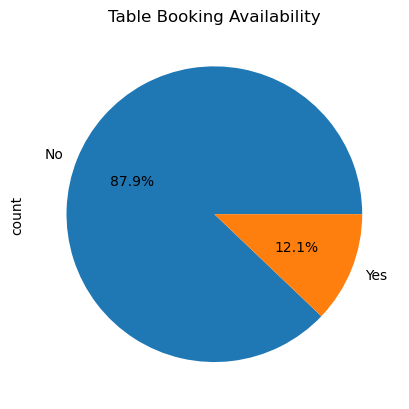

In [5]:
df['Has Table booking'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Table Booking Availability")
plt.show()

In [6]:
online_delivery_pct = (df['Has Online delivery'].value_counts(normalize=True) * 100)
print(online_delivery_pct)

Has Online delivery
No     74.337766
Yes    25.662234
Name: proportion, dtype: float64


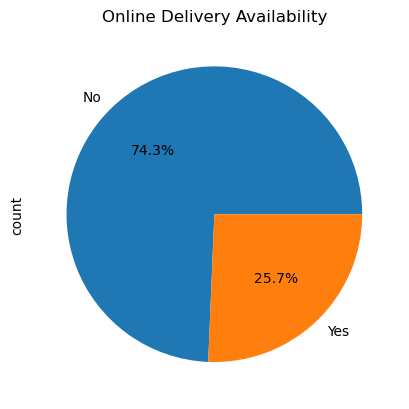

In [7]:
df['Has Online delivery'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Online Delivery Availability")
plt.show()

### :---> Average ratings of restaurants with table booking and those without.

In [8]:
df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')

In [9]:
df['Has Table booking'] = df['Has Table booking'].str.strip().str.title()          # made Consistant
df['Aggregate rating'] = pd.to_numeric(df['Aggregate rating'], errors='coerce')

#### Grouping the data

In [10]:
avg_ratings = df.groupby('Has Table booking')['Aggregate rating'].mean()
print(avg_ratings)

Has Table booking
No     2.559359
Yes    3.441969
Name: Aggregate rating, dtype: float64


#### Visualization

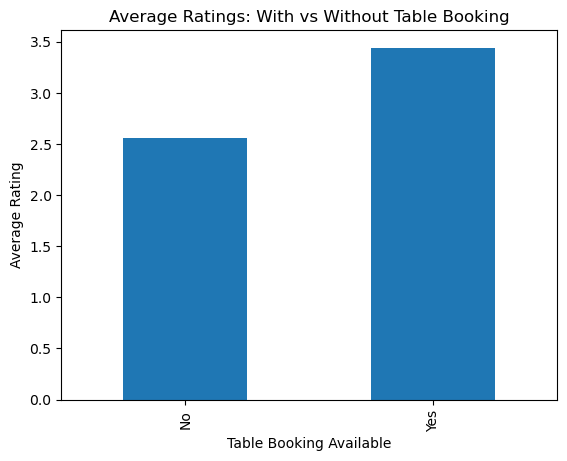

In [11]:
df.groupby('Has Table booking')['Aggregate rating'].mean().plot(kind='bar')

plt.title("Average Ratings: With vs Without Table Booking")
plt.ylabel("Average Rating")
plt.xlabel("Table Booking Available")
plt.show()

#### This suggests customers tend to rate restaurants with better reservation experience more positively.As table booking indicates better service quality, management, or a premiu|m experience.

### :---> availability of online delivery among restaurants with different price ranges.

In [12]:
df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')

In [13]:
df['Has Online delivery'] = df['Has Online delivery'].str.strip().str.title()
df['Price range'] = pd.to_numeric(df['Price range'], errors='coerce')

In [14]:
online_delivery_by_price = df.groupby('Price range')['Has Online delivery'].value_counts(normalize=True).mul(100).rename('percentage').reset_index()
print(online_delivery_by_price)

   Price range Has Online delivery  percentage
0            1                  No   84.225923
1            1                 Yes   15.774077
2            2                  No   58.689367
3            2                 Yes   41.310633
4            3                  No   70.809659
5            3                 Yes   29.190341
6            4                  No   90.955631
7            4                 Yes    9.044369


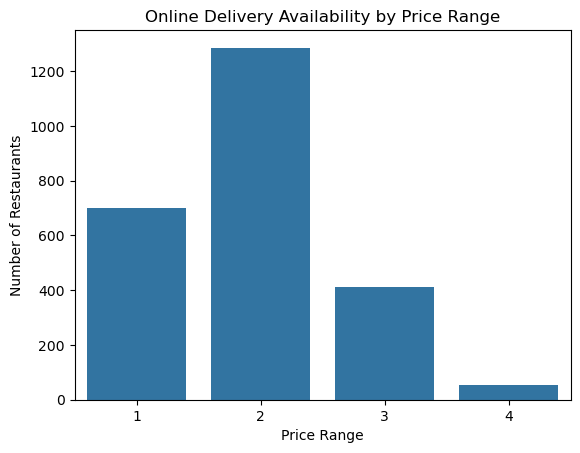

In [15]:
import matplotlib.pyplot as plt

yes_only = df[df['Has Online delivery'] == 'Yes']

sns.countplot(data=yes_only, x='Price range')
plt.title("Online Delivery Availability by Price Range")
plt.ylabel("Number of Restaurants")
plt.xlabel("Price Range")
plt.show()

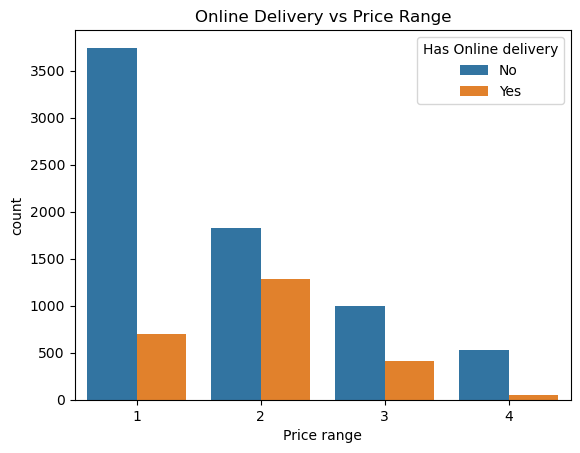

In [16]:
sns.countplot(data=df, x='Price range', hue='Has Online delivery')
plt.title("Online Delivery vs Price Range")
plt.show()

A typical pattern looks like:

Cheaper restaurants (price range 1 & 2) offer online delivery more frequently
Expensive restaurants (price range 3 & 4) offer delivery less frequently

This makes sense because:

Low/mid-budget restaurants rely heavily on online platforms for business.
Premium restaurants focus on dine-in experience, so delivery is less essential.

Write your insights like this:

“Online delivery is most common in lower price ranges (1–2), with more than 80% of restaurants offering it.
In contrast, higher price ranges (3–4) show significantly lower delivery availability.
This indicates that budget-friendly restaurants depend more on online orders, while premium restaurants prioritize dine-in service.”

# Task 2 : --> Price range Analysis

In [17]:
most_common_price_range = df['Price range'].value_counts().idxmax()
print("Most common price range:", most_common_price_range)

Most common price range: 1


In [18]:
print(df['Price range'].value_counts())

Price range
1    4444
2    3113
3    1408
4     586
Name: count, dtype: int64


In [22]:
counts = df['Price range'].value_counts()

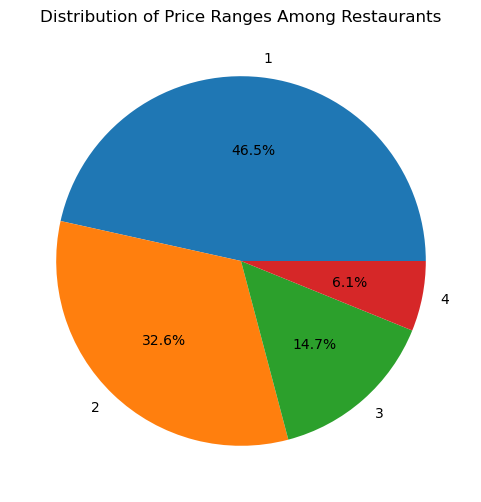

In [23]:
plt.figure(figsize=(6,6))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%')
plt.title("Distribution of Price Ranges Among Restaurants")
plt.show()

#### So from here We can pick the most popular Price Range as 1 

# Identify the rating color with highest average rating

### WE will use Zomato assigns colors such as:

#### Dark Green → Excellent
#### Green → Good
#### Yellow → Average
#### Orange → Poor
#### Red → Very Poor

In [24]:
avg_rating_by_color = df.groupby('Rating color')['Aggregate rating'].mean()
print(avg_rating_by_color)

Rating color
Dark Green    4.659801
Green         4.168119
Orange        3.051619
Red           2.297849
White         0.000000
Yellow        3.683429
Name: Aggregate rating, dtype: float64


In [25]:
top_color = avg_rating_by_color.idxmax()
print("Color with highest avg rating:", top_color)

Color with highest avg rating: Dark Green


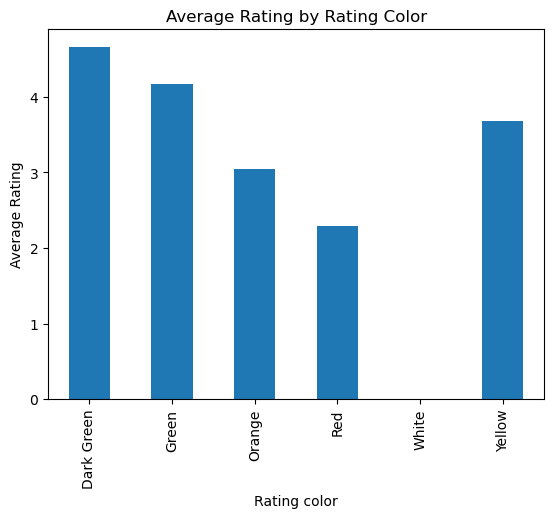

In [26]:
avg_rating_by_color.plot(kind='bar')
plt.title("Average Rating by Rating Color")
plt.ylabel("Average Rating")
plt.show()

# Feature Engineering

In [27]:
# 1. Length of restaurant name
df['Name_length'] = df['Restaurant Name'].astype(str).apply(len)

# 2. Length of address
df['Address_length'] = df['Address'].astype(str).apply(len)

# 3. Number of cuisines offered
df['Cuisine_count'] = df['Cuisines'].astype(str).apply(lambda x: len(x.split(',')))

# 4. Premium flag based on price range (1–4)
df['Is_premium'] = df['Price range'].apply(lambda x: 1 if x >= 3 else 0)

In [28]:
# Clean values
df['Has Table booking'] = df['Has Table booking'].str.strip().str.title()
df['Has Online delivery'] = df['Has Online delivery'].str.strip().str.title()

# Encode
df['Table_booking_flag'] = df['Has Table booking'].map({'Yes': 1, 'No': 0})
df['Online_delivery_flag'] = df['Has Online delivery'].map({'Yes': 1, 'No': 0})


In [29]:
df[['Restaurant Name', 'Name_length', 
    'Address', 'Address_length', 
    'Cuisines', 'Cuisine_count',
    'Price range', 'Is_premium',
    'Table_booking_flag', 'Online_delivery_flag'
   ]].head()


,Restaurant Name,Name_length,Address,Address_length,Cuisines,Cuisine_count,Price range,Is_premium,Table_booking_flag,Online_delivery_flag
0,Le Petit Souffle,16,"Third Floor, Century City Mall, Kalayaan Avenu...",71,"French, Japanese, Desserts",3,3,1,1,0
1,Izakaya Kikufuji,16,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...",67,Japanese,1,3,1,1,0
2,Heat - Edsa Shangri-La,22,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...",56,"Seafood, Asian, Filipino, Indian",4,4,1,1,0
3,Ooma,4,"Third Floor, Mega Fashion Hall, SM Megamall, O...",70,"Japanese, Sushi",2,4,1,0,0
4,Sambo Kojin,11,"Third Floor, Mega Atrium, SM Megamall, Ortigas...",64,"Japanese, Korean",2,4,1,1,0


# Level 3

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [33]:
features = [
    'Name_length', 'Address_length', 'Cuisine_count', 'Price range',
    'Is_premium', 'Table_booking_flag', 'Online_delivery_flag', 'Votes'
]

In [34]:
X = df[features]
y = df['Aggregate rating']

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)      # Train-test split

In [38]:
lr = LinearRegression()
lr.fit(X_train, y_train)                       # 1. Linear Regression
lr_pred = lr.predict(X_test)

In [39]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)                               # 2. Decision Tree
dt_pred = dt.predict(X_test)

In [40]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)                          # 3. Random Forest
rf_pred = rf.predict(X_test)

In [41]:
# Evaluation function
def evaluate_model(name, y_true, y_pred):
    print(f"--- {name} ---")
    print("R2 Score:", r2_score(y_true, y_pred))
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print()

In [43]:
# Evaluate all
evaluate_model("Linear Regression", y_test, lr_pred)
evaluate_model("Decision Tree", y_test, dt_pred)
evaluate_model("Random Forest", y_test, rf_pred)

--- Linear Regression ---
R2 Score: 0.2664078379983673
MAE: 1.0793142607740025
RMSE: 1.2921825394086113

--- Decision Tree ---
R2 Score: 0.8984100833295976
MAE: 0.31145996860282577
RMSE: 0.4808635177036142

--- Random Forest ---
R2 Score: 0.94672291224841
MAE: 0.22799343400363808
RMSE: 0.3482304673759913



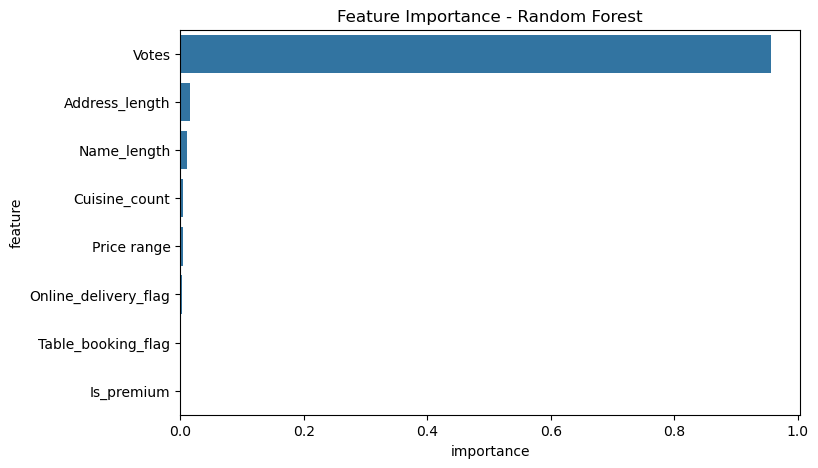

In [44]:
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(data=importance, x='importance', y='feature')
plt.title("Feature Importance - Random Forest")
plt.show()

In [45]:
# Split cuisines into individual rows
df_exploded = df.assign(cuisine=df['Cuisines'].str.split(', ')).explode('cuisine')

In [46]:
# Average rating per cuisine
cuisine_rating = df_exploded.groupby('cuisine')['Aggregate rating'].mean().sort_values(ascending=False)

In [47]:
# Total votes per cuisine
cuisine_votes = df_exploded.groupby('cuisine')['Votes'].sum().sort_values(ascending=False)

In [48]:
# Top cuisines by rating
print("Top cuisines by rating:")
print(cuisine_rating.head(10))

# Top cuisines by votes
print("\nMost popular cuisines by votes:")
print(cuisine_votes.head(10))

Top cuisines by rating:
cuisine
Sunda         4.900000
B�_rek        4.700000
Taiwanese     4.650000
Ramen         4.500000
Dim Sum       4.466667
Hawaiian      4.412500
Bubble Tea    4.400000
D�_ner        4.400000
Curry         4.400000
Kebab         4.380000
Name: Aggregate rating, dtype: float64

Most popular cuisines by votes:
cuisine
North Indian    595981
Chinese         364351
Italian         329265
Continental     288255
Fast Food       184058
American        183117
Cafe            177568
Mughlai         151946
Desserts        105889
Asian           104303
Name: Votes, dtype: int64


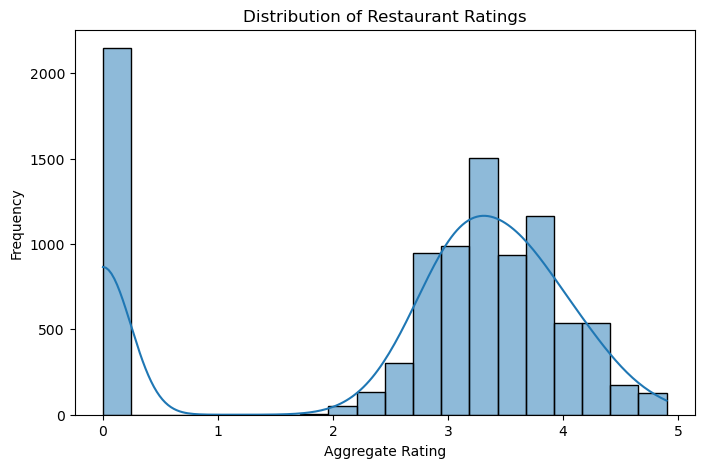

In [49]:
plt.figure(figsize=(8,5))
sns.histplot(df['Aggregate rating'], bins=20, kde=True)
plt.title("Distribution of Restaurant Ratings")
plt.xlabel("Aggregate Rating")
plt.ylabel("Frequency")
plt.show()

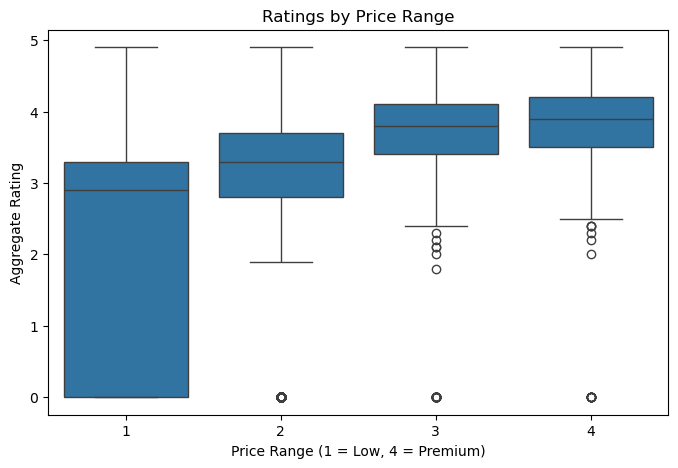

In [50]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Price range', y='Aggregate rating')
plt.title("Ratings by Price Range")
plt.xlabel("Price Range (1 = Low, 4 = Premium)")
plt.ylabel("Aggregate Rating")
plt.show()

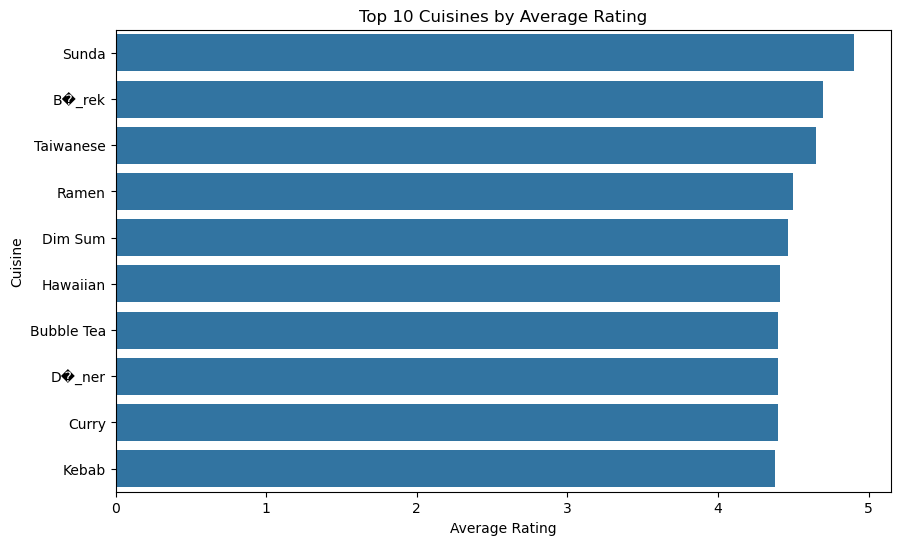

In [51]:
df_exploded = df.assign(cuisine=df['Cuisines'].str.split(', ')).explode('cuisine')

top_cuisine_rating = df_exploded.groupby('cuisine')['Aggregate rating'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_cuisine_rating.values, y=top_cuisine_rating.index)
plt.title("Top 10 Cuisines by Average Rating")
plt.xlabel("Average Rating")
plt.ylabel("Cuisine")
plt.show()

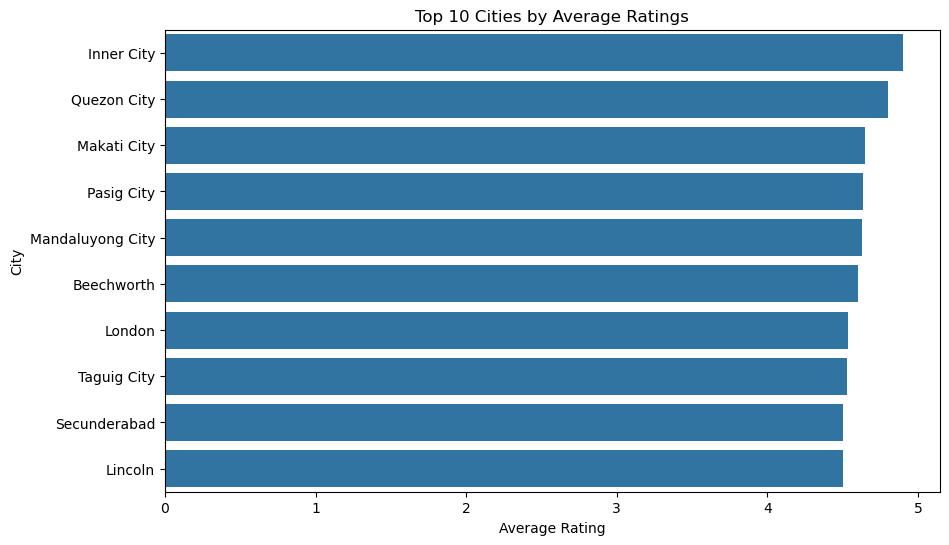

In [52]:
top_cities = df.groupby('City')['Aggregate rating'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_cities.values, y=top_cities.index)
plt.title("Top 10 Cities by Average Ratings")
plt.xlabel("Average Rating")
plt.ylabel("City")
plt.show()

In [55]:
df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes', 'Name_length', 'Address_length', 'Cuisine_count', 'Is_premium',
       'Table_booking_flag', 'Online_delivery_flag'],
      dtype='object')

### Heatmap for correlation insighjt

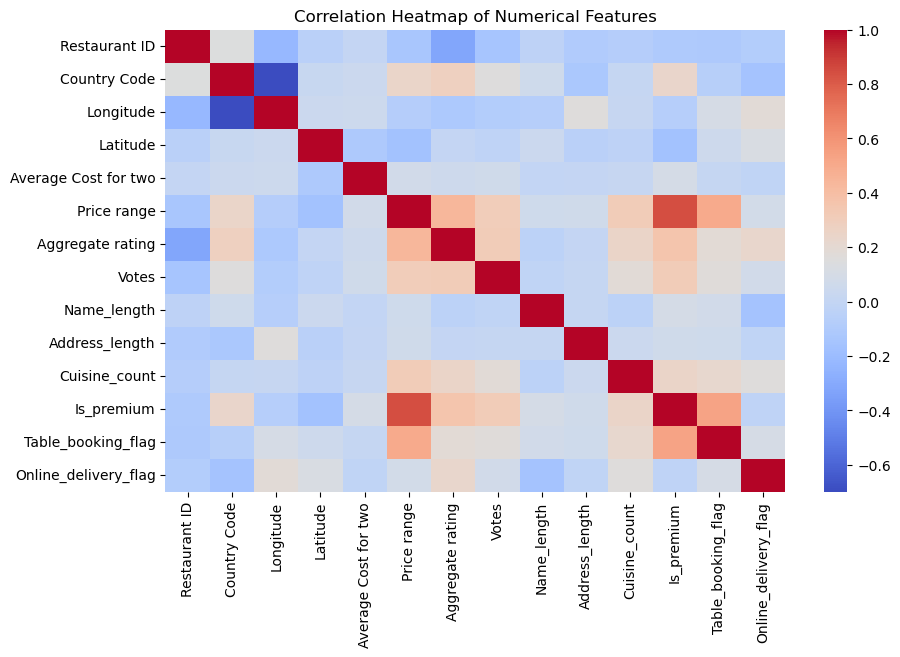

In [57]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=False, cmap='coolwarm')
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

# Final Insight 

### After generating the visuals, you will write insights like:

Distribution Analysis

Most ratings cluster around 3.5–4.5, indicating generally positive customer sentiment.

Price Range Impact

Premium restaurants (price range 3–4) maintain significantly higher ratings compared to low-price restaurants.

Cuisine Preferences

Cuisines like Japanese, Korean, French, Italian tend to have the highest average ratings.

City Trends

Cities such as Makati City and Mandaluyong show consistently higher restaurant ratings.

Feature Correlations

Votes and price range have the strongest correlation with rating—confirming earlier modeling insights.